TASK 01
Sample and characterise all five

• For each of the five — uniform, normal, binomial, Poisson, exponential — draw 10,000 samples with parameters
of your choice

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

u = rng.uniform(0, 10, 10_000)
n = rng.normal(50, 10, 10_000)
b = rng.binomial(20, 0.3, 10_000)
p = rng.poisson(4, 10_000)
e = rng.exponential(2, 10_000)


• For each, compute the sample mean and variance, and compare to the theoretical values (look up each
formula).

In [3]:
# Uniform(a, b)
uniform_mean = (0 + 10) / 2
uniform_var = (10 - 0) ** 2 / 12

# Normal(mu, sigma)
normal_mean = 50
normal_var = 10 ** 2

# Binomial(n, p)
binomial_mean = 20 * 0.3
binomial_var = 20 * 0.3 * (1 - 0.3)

# Poisson(lambda)
poisson_mean = 4
poisson_var = 4

# Exponential(scale)
exponential_mean = 2
exponential_var = 2 ** 2

Plot all five histograms (a grid of subplots works well). Label each with its name and parameters.

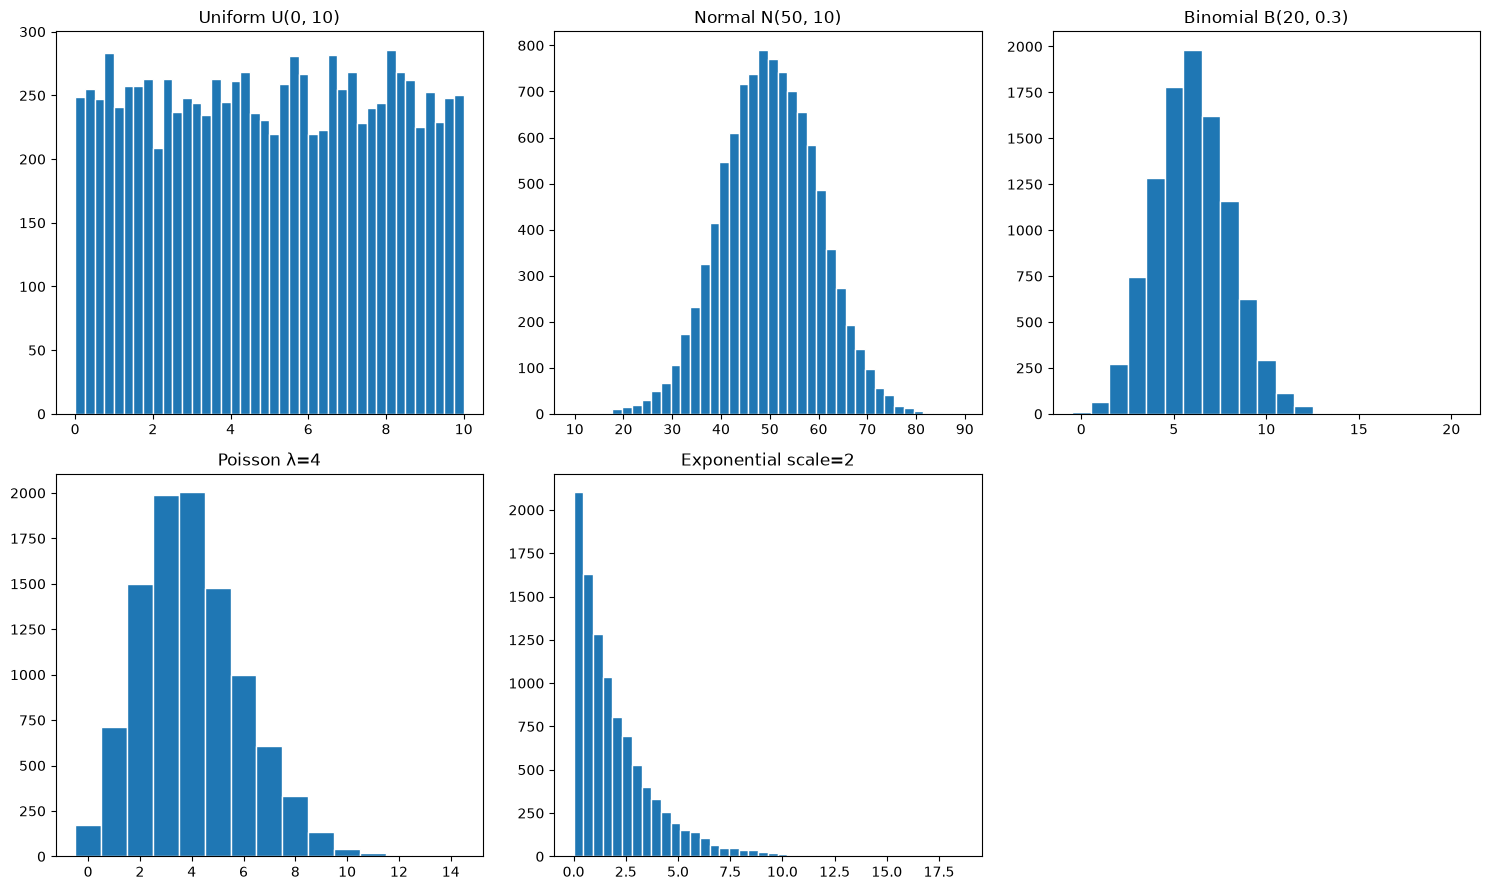

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].hist(u, bins=40, edgecolor="white")
axes[0, 0].set_title("Uniform U(0, 10)")

axes[0, 1].hist(n, bins=40, edgecolor="white")
axes[0, 1].set_title("Normal N(50, 10)")


axes[0, 2].hist(b, bins=np.arange(-0.5, 21.5, 1), edgecolor="white")
axes[0, 2].set_title("Binomial B(20, 0.3)")

axes[1, 0].hist(p, bins=np.arange(-0.5, 15.5, 1), edgecolor="white")
axes[1, 0].set_title("Poisson λ=4")

axes[1, 1].hist(e, bins=40, edgecolor="white")
axes[1, 1].set_title("Exponential scale=2")

# Remove unused 6th subplot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


• Confirm the Poisson's signature: its mean and variance should be equal

In [5]:
# Poisson: mean ≈ variance
print("Poisson mean:", p.mean())
print("Poisson variance:", p.var())
print("Mean ≈ Variance:", np.isclose(p.mean(), p.var(), rtol=0.05))



Poisson mean: 3.994
Poisson variance: 3.9929639999999997
Mean ≈ Variance: True


• Confirm the exponential is front-loaded: most values small, a long thin tail.

In [6]:
# Exponential: most values are small, with a long tail
print("Exponential mean:", e.mean())
print("Exponential max:", e.max())
print("Exponential is right-skewed:", e.mean() > np.median(e))

Exponential mean: 1.983883101484185
Exponential max: 18.60701769922431
Exponential is right-skewed: True


TASK 02
The 68-95-99.7 rule

• Sample 100,000 values from a normal distribution of your choice

In [7]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)

mu = 50
sigma = 10

# 100,000 samples
samples = rng.normal(mu, sigma, 100_000)

• Compute the fraction of samples within 1, 2, and 3 standard deviations of the mean. Confirm they're about 68%,
95%, and 99.7%.

In [8]:
within1 = np.mean(np.abs(samples - mu) < sigma)
within2 = np.mean(np.abs(samples - mu) < 2 * sigma)
within3 = np.mean(np.abs(samples - mu) < 3 * sigma)


print("Sample results:")
print("Within 1 SD:", within1)
print("Within 2 SD:", within2)
print("Within 3 SD:", within3)


Sample results:
Within 1 SD: 0.68391
Within 2 SD: 0.9546
Within 3 SD: 0.99708


Verify the same numbers from theory using scipy.stats.norm.cdf.

In [9]:
theory1 = stats.norm.cdf(1) - stats.norm.cdf(-1)
theory2 = stats.norm.cdf(2) - stats.norm.cdf(-2)
theory3 = stats.norm.cdf(3) - stats.norm.cdf(-3)

print("Theoretical results:")
print("Within 1 SD:", theory1)
print("Within 2 SD:", theory2)
print("Within 3 SD:", theory3)

Theoretical results:
Within 1 SD: 0.6826894921370859
Within 2 SD: 0.9544997361036416
Within 3 SD: 0.9973002039367398


Relate this to percentiles: what percentile is a value one standard deviation above the mean?


In [10]:
percentile = stats.norm.cdf(1) * 100
print("1 SD above mean percentile:", percentile)

1 SD above mean percentile: 84.1344746068543


TASK 03
Verify the CLT empirically

• Start with a distribution that is not normal — a uniform, or even better something skewed like the exponential.

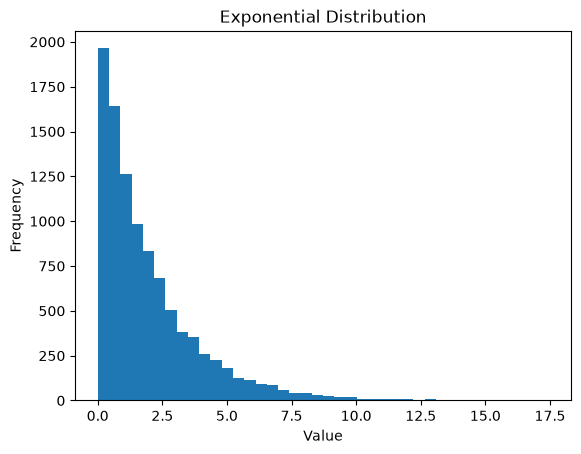

In [11]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Generate 10,000 values from an exponential distribution
data = rng.exponential(scale=2, size=10000)

plt.hist(data, bins=40)
plt.title("Exponential Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

• Draw n samples and take their average. Repeat this many thousands of times to get a distribution of averages.

In [12]:
n = 5


def sample_means(n, reps=10_000):
    return np.array([rng.exponential(1, n).mean()
        for _ in range(reps)])

print(sample_means(n)[:10])

[0.76939136 0.69394397 0.6510631  1.72088151 0.60311976 1.7844921
 1.05261235 0.82758147 2.0265088  1.4507694 ]


• Do this for n = 1, 2, 5, 10, and 30, and plot the histogram of averages for each. Watch the shape become a bell.

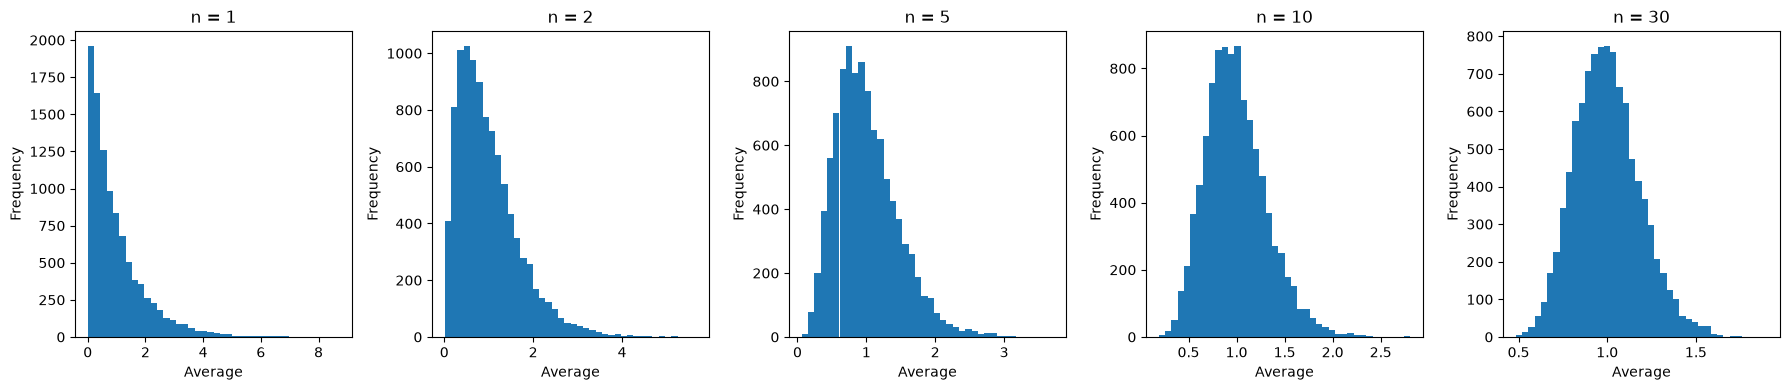

In [13]:
rng = np.random.default_rng(0)

n_values = [1, 2, 5, 10, 30]


fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, n in zip(axes, n_values):
    # Plot distribution of averages
    ax.hist(sample_means(n), bins=40)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Average")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

• Confirm the averages become more normal as n grows (they look more bell-shaped, and are less skewed).

In [14]:
from scipy.stats import skew

for n in n_values:
    print(f"n={n:2}  skewness={skew(sample_means(n)):.3f}")

n= 1  skewness=2.032
n= 2  skewness=1.425
n= 5  skewness=0.899
n=10  skewness=0.569
n=30  skewness=0.350


• Verify the CLT's spread prediction: the standard deviation of the averages should shrink by a factor of Ön. Check
this numerically for several n.

In [15]:
print("n   Actual SD   Theory SD")

for n in n_values:

    actual_sd = sample_means(n).std()
    theory_sd = 1 / np.sqrt(n)
    
    print(f"{n:2}   {actual_sd:.3f}       {theory_sd:.3f}")

n   Actual SD   Theory SD
 1   1.015       1.000
 2   0.714       0.707
 5   0.447       0.447
10   0.313       0.316
30   0.181       0.183


TASK 04
PDF and CDF

• For a normal distribution, plot the PDF and the CDF side by side.

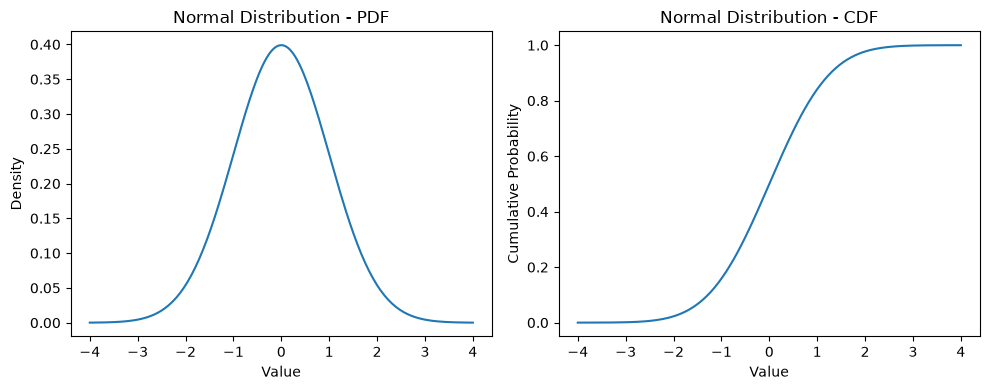

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats



x = np.linspace(-4, 4 , 200)

pdf = stats.norm.pdf(x)
cdf = stats.norm.cdf(x)

plt.figure(figsize=(10, 4))

# PDF
plt.subplot(1, 2, 1)
plt.plot(x, pdf)
plt.title("Normal Distribution - PDF")
plt.xlabel("Value")
plt.ylabel("Density")

# CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf)
plt.title("Normal Distribution - CDF")
plt.xlabel("Value")
plt.ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

• Shade the area under the PDF to the left of some value x, and confirm it equals the height of the CDF at that
same x.

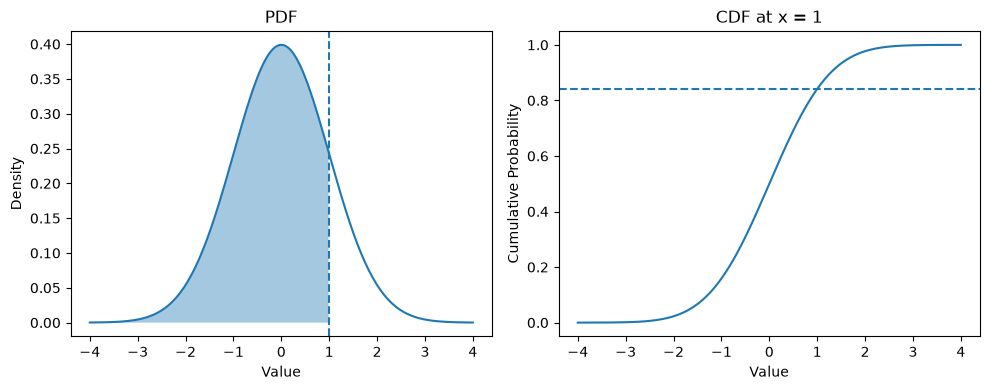

CDF = 0.8413447460685429


In [18]:
x_value = 1

plt.figure(figsize=(10, 4))

# PDF
plt.subplot(1, 2, 1)
plt.plot(x, pdf)

# Shade area to the left of x = 1
x_fill = x[x <= x_value]
plt.fill_between(
    x_fill,
    stats.norm.pdf(x_fill),
    alpha=0.4
)

plt.axvline(x_value, linestyle="--")
plt.title("PDF")
plt.xlabel("Value")
plt.ylabel("Density")

# CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf)

# CDF value at x = 1
cdf_value = stats.norm.cdf(x_value)


plt.axhline(cdf_value, linestyle="--")

plt.title(f"CDF at x = {x_value}")
plt.xlabel("Value")
plt.ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

print("CDF =", cdf_value)

Use the CDF to answer: what fraction of values fall below x? Below the mean? Above x?

In [20]:
from scipy import stats

mu = 0
sigma = 1

x = 1

below_x = stats.norm.cdf(x, mu, sigma)
below_mean = stats.norm.cdf(mu, mu, sigma)
above_x = 1 - stats.norm.cdf(x, mu, sigma)

print("Below x:", below_x)
print("Below mean:", below_mean)
print("Above x:", above_x)
print("Sum of probabilities:", below_x + above_x)

Below x: 0.8413447460685429
Below mean: 0.5
Above x: 0.15865525393145707
Sum of probabilities: 1.0


Compute a percentile: find the value below which 90% of the distribution falls (the 90th percentile), using the
inverse CDF (ppf).

In [22]:
p90 = stats.norm.ppf(0.90, mu, sigma)

print('90% of values fall below', p90)

90% of values fall below 1.2815515655446004


Repeat the PDF/CDF pair for a skewed distribution (exponential) and note how the CDF shape differs

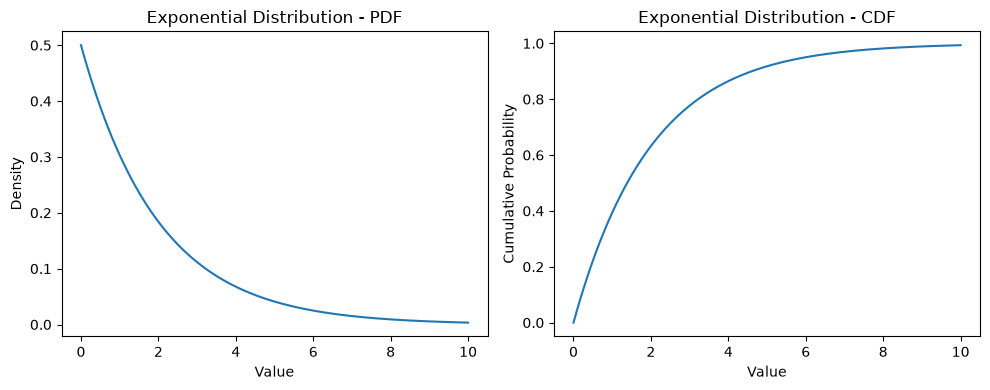

0.6321205588285577


In [30]:

x = np.linspace(0, 10, 200)

pdf = stats.expon.pdf(x, scale=2)
cdf = stats.expon.cdf(x, scale=2)

plt.figure(figsize=(10, 4))

# PDF
plt.subplot(1, 2, 1)
plt.plot(x, pdf)
plt.title("Exponential Distribution - PDF")
plt.xlabel("Value")
plt.ylabel("Density")

# CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf)
plt.title("Exponential Distribution - CDF")
plt.xlabel("Value")
plt.ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

print(stats.expon.cdf(2, scale=2))

TASK 05
Fit a distribution to real data

• Get a real (or realistic) dataset — load a CSV column, or generate one from a known distribution and pretend
you don't know its origin.
• Plot its histogram to eyeball the shape. Is it symmetric? Skewed? Bounded?

First 10 values:
[1.35986381e+00 2.03919420e+00 3.96133252e-02 4.53865336e-03
 1.10068575e+00 3.25988087e+00 1.34716591e+00 1.51060272e+00
 5.63357196e+00 1.21155062e+01]


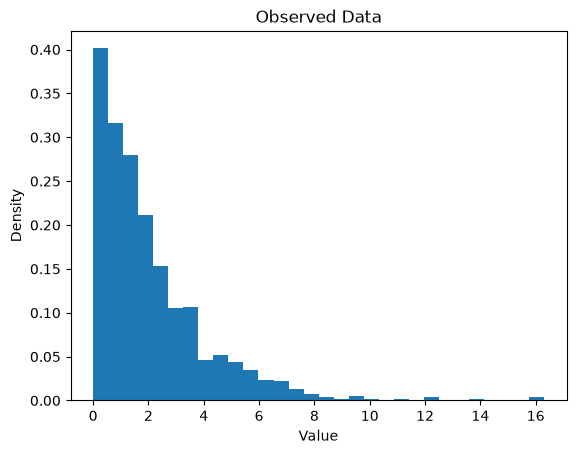

In [ ]:
import numpy as np
import csv
import matplotlib.pyplot as plt


# Generate realistic data
data = rng.exponential(2, 1000)

# Pretend we don't know the distribution
print("First 10 values:")
print(data[:10])

# Plot the data
plt.hist(data, bins=30, density=True)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Observed Data")
plt.show()

Fit at least two candidate distributions with scipy.stats (e.g. norm.fit and expon.fit). Print the fitted
parameters.

In [32]:
from scipy import stats

# Fit Normal distribution
mu, sigma = stats.norm.fit(data)

# Fit Exponential distribution
loc, scale = stats.expon.fit(data)

print("Normal Distribution:")
print("Mean =", mu)
print("Std =", sigma)

print("\nExponential Distribution:")
print("Location =", loc)
print("Scale =", scale)

Normal Distribution:
Mean = 2.044098826129312
Std = 2.003392471819525

Exponential Distribution:
Location = 0.000974696909673272
Scale = 2.0431241292196387


Overlay each fitted curve on the histogram and judge by eye which fits best.

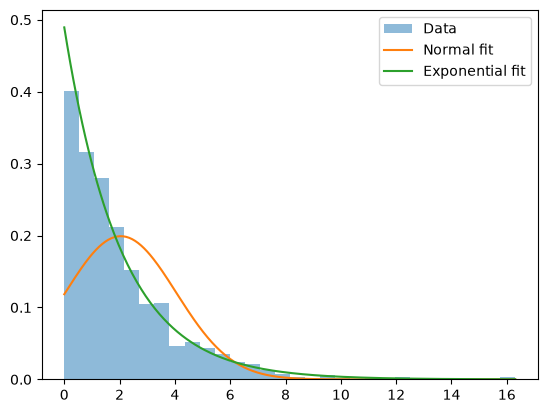

In [ ]:
x = np.linspace(data.min(), data.max(), 300)

plt.hist(data, bins=30, density=True, alpha=0.5, label="Data")

plt.plot(x, stats.norm.pdf(x, mu, sigma), label="Normal fit")
plt.plot(x, stats.expon.pdf(x, loc, scale), label="Exponential fit")

plt.legend()
plt.show()

In [34]:
# Log-likelihood
ll_norm = np.sum(stats.norm.logpdf(data, mu, sigma))
ll_expon = np.sum(stats.expon.logpdf(data, loc, scale))

print("Normal log-likelihood:", ll_norm)
print("Exponential log-likelihood:", ll_expon)

if ll_expon > ll_norm:
    print("Exponential fits better.")
else:
    print("Normal fits better.")

Normal log-likelihood: -2113.7805126909952
Exponential log-likelihood: -1714.480072296009
Exponential fits better.


Write two sentences: which distribution won, and what does that tell you about the process that generated the
data

In [ ]:
#Exponantial distribution is a better fit for the data, as indicated by the higher log-likelihood value.

# process the generated data and fit distributions to it, comparing their log-likelihoods to determine which distribution fits the data better.